# Tutorial FigureCollection with energy transfers

In [3]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.miscellaneous as mi

%load_ext autoreload
%autoreload 2

In [10]:
transitions = [['S0_S1', 7e6, "excitation", "EXC", False],  
               ['S1_S0', 1e9, "fluorescent emission", "FLU", True], 
               ['S1_T1', 1e6, "intersystem crossing ST", "ISCST", False],   
               ['T1_S0', 5e5, "intersystem crossing TS", "ISCTS", False],
               ['S1_S0', 1e9, "internal conversion S", "ICS", False],
               ['S1_Cis', 2e7, "isomerization", "ISO", False],
               ['Cis_S0', 1e5, "backisomerization", "BISO", False],
               ['T1_OFF', 1.4e6, "reduction", "RED", False],
               ['OFF_S0', 1e1, "oxidation", "OX", False],
               ['S1_S0__S0_S1', 1e11, 'energy transfer', 'FRET', False]]
               #['S1_S0__OFF_S0', 1e5, 'OFF recovery', 'RECOV', False]]

In [21]:
system = fs.Cy5(number_fluorophores=2, distances=1, transitions=transitions)
system.simulate(n_steps=int(1e7), seed=100)
system.process()
system.emitters(photon_collection_rate=0.5, resample="5ms", emccd_gain=10)
system.fcs(normalize=True, log=True, m=2, deltat="10us")

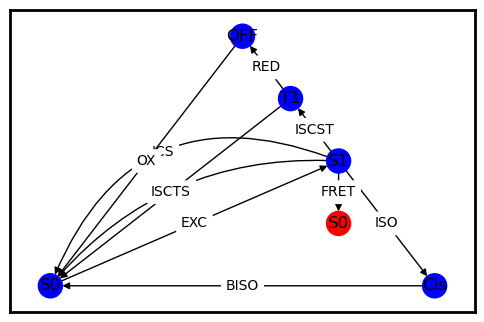

In [22]:
fig, ax = system.plot.network(type='planar')

### Energy transfers
- Do not alter the fluorescence lifetime as much as may be expected, because they do not have any impact if the acceptor fluorophore is not in the ground state. Hence, long living states like $T1$, $Cis$ and $OFF$ reduce the impact of the energy transfer on the overall fluorescence lifetime.
- Even in systems that only comprise the $S0$ and the $S1$ state, energy transfers won't occur as often as fluorescence emission, because the latter can occur if both fluorophores are in their $S1$ state.
- Since there are two fluorophores involved in energy transfer, the measured statistics must be analyzed with caution:
    - energy transfers will occur more often than it may be expected when looking at single fluorophore transition series
    - the time until the transition occurs depends not only on the part of $S1_{fluo1}$ to $S0_{fluo1}$ but also on $S0_{fluo2}$ to $S1_{fluo2}$, where the latter may have been in this state for a long time
    

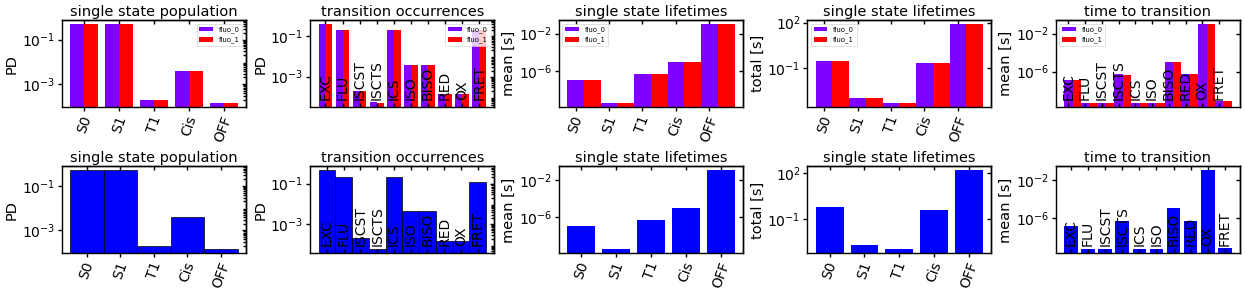

In [23]:
fig, ax = system.plot.populations(mode="single_states", single_fluorophores=True, scale=0.5, ncols=5, nrows=2, fig_width=25, fig_height=6)
_, _ = system.plot.populations(mode="single_states", single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 3])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 4])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 4])
fig.tight_layout()

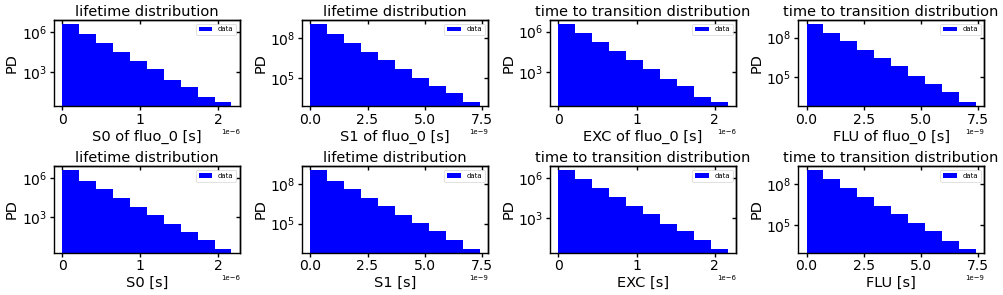

In [24]:
fig, ax = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=0, transition_id=None, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=6)
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=0, transition_id=None, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[1, 3])
fig.tight_layout()

## Emission analysis

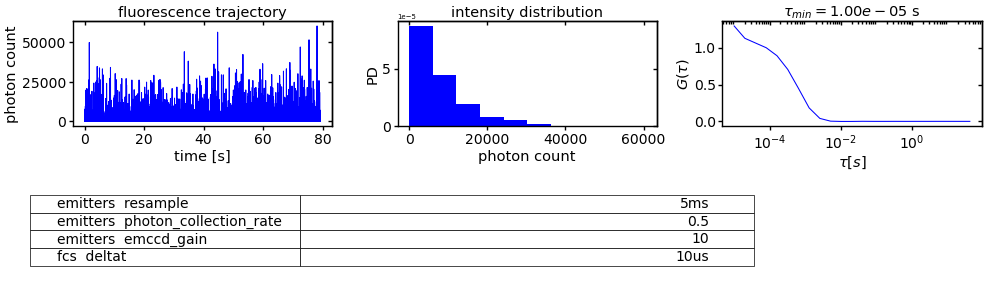

In [25]:
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=3, nrows=3, fig_width=20, fig_height=9)
_, _ = system.plot.emission_events(time_series=False, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.fcs(normalize_to=4, fig=fig, axes=ax[0, 2])
fig = mi.delete_subplots(fig, ax, 3)
fig = system.plot.add_table(fig, grid=312, level_0=['emitters', 'fcs'], level_1=[['resample', 'photon_collection_rate', 'emccd_gain'], ['deltat']],
                            scale=(0.5, 2), fontsize=20)
fig.tight_layout()

## ON OFF periods
#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.


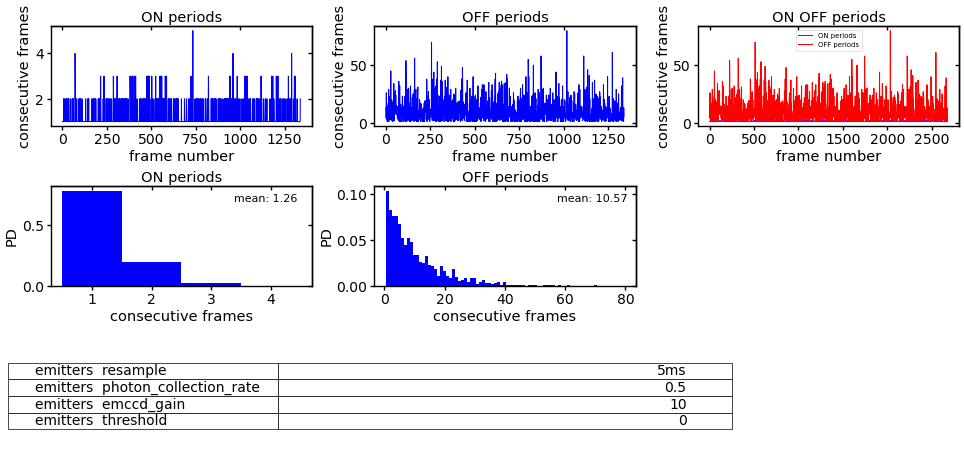

In [26]:
fig, ax = system.plot.on_off(mode='on', time_series=True, scale=0.5, ncols=3, nrows=3, fig_width=20, fig_height=9)
_, _ = system.plot.on_off(mode='off', time_series=True, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.on_off(mode='mesh', time_series=True, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.on_off(mode='on', time_series=False, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.on_off(mode='off', time_series=False, scale=1, fig=fig, axes=ax[1, 1])
fig = mi.delete_subplots(fig, ax, 5)
fig = system.plot.add_table(fig, grid=313, level_0=['emitters'], level_1=[['resample', 'photon_collection_rate', 'emccd_gain', 'threshold']],
                            scale=(0.5, 2), fontsize=20)
fig.tight_layout()